# Machine Learning for Multibody System Dynamics

## **Session 2-1:** Surrogate Modeling: Duffing Oscillator with External Forcing Revised

Grzegorz Orzechowski & Peter Manzl

> DNN trained on Duffing‐oscillator equations of motion. 
> We are building model with local mapping `(x, v, F) -> (dx/dt, dv/dt)`
> It is our first nonlinear supervised-learning example. 

In [1]:
# 1) Imports and Setup
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import random

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Duffing Oscillator 

In this file, a deep neural network is trained on the dynamics of a [Duffing oscillator](https://en.wikipedia.org/wiki/Duffing_equation). The equations of motion (EOM) are:

$$m \,\ddot{x} + d \,\dot{x} + k \,x + \alpha \,k \,x^3 = F(t).$$

In the used dataset, parameters are fixed as:
-  $m = 1$,
-  $k = 1600$,
-  $d = 8$,
-  $\alpha = 1$.


## Generate Supervised Data

We want to train a network to learn the local dynamics of the Duffing oscillator:

$$
(x,\, \dot{x},\, F) \;\mapsto\; \left(\frac{dx}{dt},\, \frac{d\dot{x}}{dt}\right)
$$

### Why sample random state-space points?

We have access to the **equations of motion** — we can evaluate the RHS analytically at any $(x, v, F)$, without running a simulation.

Compared to trajectory-based sampling:
- No autocorrelation between samples → better training statistics
- Full control over which regions of state space are covered
- Much faster to generate

### Ranges and Noise

**State-space ranges** cover the physically relevant operating regime:

| Feature | Range | Units |
|---------|-------|-------|
| $x$     | $[-2, 2]$ | m |
| $v$     | $[-100, 100]$ | m/s |
| $F$     | $[-2000, 2000]$ | N |

The $x$ range is intentionally wider than the static equilibrium amplitude under peak forcing — the **rollout reaches $|x| \approx 2$ dynamically**, and training must cover what we'll evaluate.

**5% output noise as regularization:**  
Small Gaussian noise added to computed derivatives before storing.  
Prevents exact memorization and encourages smoother, more generalizable representations.

In [2]:
# 2) Generate supervised data: (x, v, F) -> (dx/dt, dv/dt)

# parameters
N = 5_000
m = 1.0
k = 1600.0
damp = 8.0
alpha = 1.0

def duffing_equation(F, x, v):
    return F - damp * v - k * x - alpha * k * x**3

# preallocate
X = np.zeros((N, 3), dtype=np.float32)  # [x, v, F]
Y = np.zeros((N, 2), dtype=np.float32)  # [dx, dv]

# Training ranges are chosen to cover the rollout's operating envelope:
#   x in [-2, 2]   (the integrated trajectory reaches |x| ≈ 2 under our forcing)
#   v in [-100, 100]
#   F in [-2000, 2000]
rng = np.random.default_rng(seed=42)
for i in range(N):
    x = (rng.random() * 2 - 1) * 2
    v = (rng.random() * 2 - 1) * 100
    F = (rng.random() * 2 - 1) * 2000

    dx = (1 + 0.05 * rng.standard_normal()) * v
    dv = (1 + 0.05 * rng.standard_normal()) * duffing_equation(F, x, v)

    X[i] = [x, v, F]
    Y[i] = [dx, dv]


## Data Preprocessing: Normalization

The three input features have very different magnitudes:

| Feature | Typical range | Units |
|---------|--------------|-------|
| $x$     | $[-2, 2]$    | m     |
| $v$     | $[-100, 100]$ | m/s  |
| $F$     | $[-2000, 2000]$ | N  |

**Why does this matter?**  
Gradients scale with feature magnitude. With $F$ being ~1000× larger than $x$, the optimizer ignores small-scale features and overweights large ones.  
Training becomes slow, unstable, or gets stuck entirely.

### Zero Mean, Unit Variance

For each feature: subtract mean, divide by standard deviation:

$$
x_{\text{scaled}} = \frac{x - \mu}{\sigma}
$$

All features now live roughly in $[-3,\, 3]$ — gradients are balanced.

> **Data leakage warning:**  
> Scalers are fit **only on training data** (`fit_transform`), then applied to validation data (`transform`).  
> Fitting on the full dataset lets the model implicitly know validation statistics.

**At prediction time:** model outputs scaled derivatives — apply `scaler_Y.inverse_transform()` to get physical values back.

In [3]:
# 3) Initialize scalers — fitted on training data only (see DataLoaders cell below)
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

## Neural Network Architecture

We use a **Multi-Layer Perceptron (MLP)**: fully connected layers with nonlinear activations.

### `[3] → 128 → 128 → [2]`

| Layer | Size | Role |
|-------|------|------|
| Input | 3 | $(x,\, v,\, F)$ |
| Hidden 1 | 128 | nonlinear feature extraction |
| Hidden 2 | 128 | additional capacity |
| Output | 2 | $(\dot{x},\, \dot{v})$ |

Two hidden layers give more capacity than one to represent nonlinear Duffing dynamics, without being too slow for CPU training.

### Activation Function: SiLU

$$\text{SiLU}(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}$$

| | SiLU | ReLU |
|--|:----:|:----:|
| Smooth everywhere | ✓ | ✗ (corner at 0) |
| Dead neurons possible | rarely | yes |
| Gradient at 0 | non-zero | zero |

SiLU's smoothness matters when learning continuous physical dynamics — derivatives exist everywhere, which aids optimization.

### Optimizer and Hyperparameter Values

**AdamW** = Adam + decoupled weight decay  
Regularization penalty applied directly to weights, not mixed into gradient estimates — better-behaved than standard Adam + L2.

| Parameter | Value | Source |
|-----------|-------|--------|
| `hidden_dims` | `[128, 128]` | capacity vs. speed |
| `dropout_rate` | `0.011` | grid search (see 2-3) |
| `learning_rate` | `1e-3` | standard starting point |
| `weight_decay` | `1e-4` | light L2 penalty |
| `patience` | `50` | early stopping |

In [4]:
# 4) Build the MLP surrogate model

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes, output_dim, dropout_rate=0.0, activation=nn.SiLU):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(activation())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            in_dim = h
        layers.append(nn.Linear(in_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# settings - our hyper-parameters
hidden_dims   = [128, 128]
dropout_rate  = 0.011
activation    = nn.SiLU
batch_size    = 64
learning_rate = 1e-3
weight_decay  = 1e-4
patience      = 50
n_epochs      = 2000

model = MLP(3, hidden_dims, 2, dropout_rate, activation).to(device)


## Regularization in Neural Networks

<img src="../figures/overfitting.png" alt="overfitting" width="280" align="right" style="padding: 20px;" />

**Overfitting:** model fits training data well, fails on unseen data.

**Common Techniques**

| Technique | Mechanism |
|-----------|-----------|
| **L2 Weight Decay** | Penalize large weights: $+\lambda\|w\|^2$ |
| **Dropout** | Randomly disable neurons each step |
| **Early Stopping** | Halt when validation loss plateaus |
| **Data Augmentation** | Add noise/shifts to expand dataset |
| **Batch Normalization** | Normalize activations per mini-batch |

### Regularization: Practical Guidelines

**Typical ranges:**
- **L2 λ (weight decay):** $10^{-6}$ to $10^{-2}$
- **Dropout rate:** 0.1 – 0.5
- Combine multiple methods for best generalization

**AdamW vs. Adam + L2:**

- Standard Adam with L2 mixes the penalty into adaptive moment estimates → distorts step sizes
- AdamW applies weight decay directly, after the Adam update → cleaner regularization
- In practice: always prefer `AdamW` over `Adam` when using weight decay

In [5]:
# 5) Train/val split, then fit scalers on training data only
indices = np.arange(N)
np.random.shuffle(indices)
split = int(0.8 * N)
train_idx, val_idx = indices[:split], indices[split:]

# Fit on training data, then transform val data separately — no data leakage
X_train_scaled = scaler_X.fit_transform(X[train_idx])
Y_train_scaled = scaler_Y.fit_transform(Y[train_idx])
X_val_scaled   = scaler_X.transform(X[val_idx])
Y_val_scaled   = scaler_Y.transform(Y[val_idx])

X_train = torch.from_numpy(X_train_scaled).float().to(device)
Y_train = torch.from_numpy(Y_train_scaled).float().to(device)
X_val   = torch.from_numpy(X_val_scaled).float().to(device)
Y_val   = torch.from_numpy(Y_val_scaled).float().to(device)

train_loader = DataLoader(TensorDataset(X_train, Y_train),
                          batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, Y_val),
                          batch_size=batch_size, shuffle=False)

## Training Loop

Three steps per epoch:

1. **Forward pass** — compute predictions from current weights
2. **Backward pass** — compute gradients via backpropagation
3. **Optimizer step** — update weights to reduce loss

After each epoch: compute **validation loss** to monitor generalization.  
**Early stopping:** halt training when validation loss stops improving for `patience` epochs and restore the best weights seen so far.

In [6]:
# 6) Training loop with early stopping
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

train_loss_hist = []
val_loss_hist   = []
best_val = float('inf')
no_improve = 0

for epoch in range(1, n_epochs + 1):
    # Training
    model.train()
    total_train = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_train += loss.item()
    train_loss_hist.append(total_train / len(train_loader))

    # Validation
    model.eval()
    total_val = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model(xb)
            total_val += criterion(preds, yb).item()
    val_loss = total_val / len(val_loader)
    val_loss_hist.append(val_loss)

    # Early stopping
    if val_loss < best_val:
        best_val = val_loss
        no_improve = 0
        best_state = model.state_dict()
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# load best model
model.load_state_dict(best_state)
print(f"Final validation loss: {val_loss_hist[-1]:.6f}")

Early stopping at epoch 155
Final validation loss: 0.002984


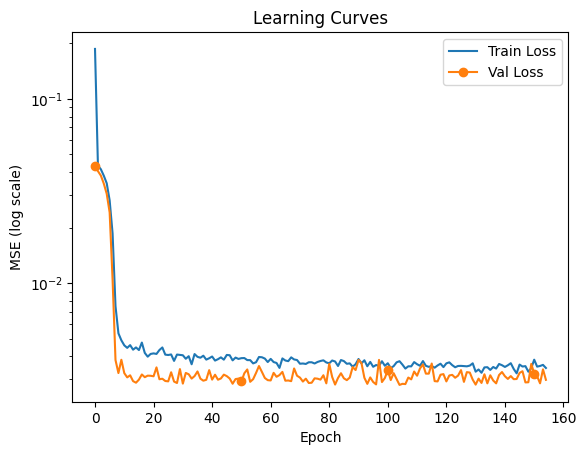

In [7]:
# 7) Plot training & validation loss
plt.figure()
plt.semilogy(train_loss_hist, label='Train Loss')
plt.semilogy(val_loss_hist,   label='Val Loss', marker='o', markevery=50)
plt.xlabel('Epoch')
plt.ylabel('MSE (log scale)')
plt.legend()
plt.title('Learning Curves')
plt.show()

## One-Step Error vs. Rollout Error

This is the **central challenge** of learned ODE surrogates.

### The mismatch

Training: independent samples — each $(x, v, F)$ drawn randomly from state space.  
Testing: **integrate forward in time** — network output at step $k$ becomes input at step $k+1$.

Errors compound at every step:

$$
\underbrace{\varepsilon_1}_{\text{step 1}} \;\rightarrow\; \underbrace{\varepsilon_1 + \varepsilon_2}_{\text{step 2}} \;\rightarrow\; \underbrace{\varepsilon_1 + \varepsilon_2 + \varepsilon_3}_{\text{step 3}} \;\rightarrow\; \cdots$$

Each small error shifts the state to a point the network may never have seen during training.

### Why Low Validation Loss ≠ Good Rollout

The validation loss measures **one-step accuracy** in isolation:

- One-step error $10^{-4}$ over 64 steps → compounded error can be $\gg 1$
- Network is **never penalized** during training for what happens 10 steps later
- Nonlinear systems amplify small errors (sensitivity to initial conditions)

**Always test surrogates with full trajectory integration — not just loss curves.**

### What can be done?

- **Session 2-2:** trajectory-based training sidesteps this by design
- **Multi-step loss:** penalize rollout error during training
- **Physics-informed constraints:** embed conservation laws in the loss

## Interactive Burst

If validation loss looks good here, do you expect the integrated trajectory to stay accurate for the whole horizon?

## Compare Surrogate vs True Trajectory

Select a random test forcing sequence and plot the true Duffing integration against the surrogate’s prediction.


In [8]:
# 8) Define ODE right‐hand sides
model.eval()  # dropout off
def surrogate_rhs(t, u, forces, h):
    # u = [x, v]
    idx = min(int(t / h), len(forces)-1)
    F_t = forces[idx]
    inp = np.array([[u[0], u[1], F_t]], dtype=np.float32)
    inp_s = scaler_X.transform(inp)
    with torch.no_grad():
        dud_s = model(torch.from_numpy(inp_s).to(device)).cpu().numpy()
    dud = scaler_Y.inverse_transform(dud_s)
    return [dud[0,0], dud[0,1]]

def duffing_rhs(t, u, forces, h):
    idx = min(int(t / h), len(forces)-1)
    F_t = forces[idx]
    x, v = u
    return [v, duffing_equation(F_t, x, v)]


In [9]:
# 9) Simulate and compare
n_steps = 64
h = 0.5 / 64
t_span = (0.0, h * n_steps)
t_eval = np.linspace(*t_span, n_steps+1)
# Forces drawn from the training distribution so the rollout doesn't extrapolate.
forces = (rng.random(n_steps) * 2 - 1) * 2000

u0 = [0.1, 0.0]

# surrogate solution
sol_sur = solve_ivp(fun=lambda t, y: surrogate_rhs(t, y, forces, h),
                    t_span=t_span, y0=u0, t_eval=t_eval, method='RK45')

# true solution
sol_true = solve_ivp(fun=lambda t, y: duffing_rhs(t, y, forces, h),
                     t_span=t_span, y0=u0, t_eval=t_eval, method='RK45')


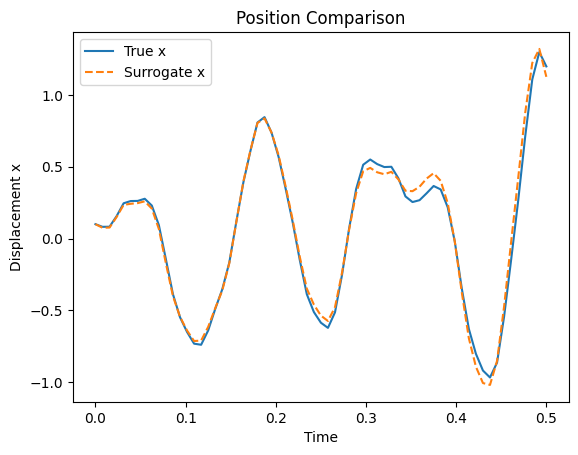

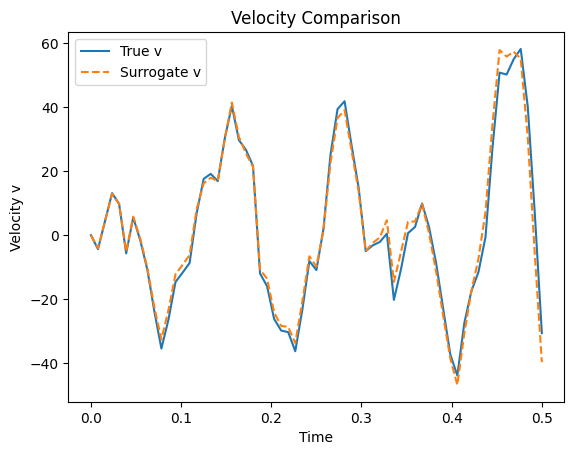

In [10]:
# 10) Plot trajectories
plt.figure()
plt.plot(sol_true.t, sol_true.y[0], label='True x')
plt.plot(sol_sur .t, sol_sur .y[0], '--', label='Surrogate x')
plt.xlabel('Time')
plt.ylabel('Displacement x')
plt.legend()
plt.title('Position Comparison')
plt.show()

plt.figure()
plt.plot(sol_true.t, sol_true.y[1], label='True v')
plt.plot(sol_sur .t, sol_sur .y[1], '--', label='Surrogate v')
plt.xlabel('Time')
plt.ylabel('Velocity v')
plt.legend()
plt.title('Velocity Comparison')
plt.show()


## Discussion Prompt

Which failure appears first in the surrogate rollout: phase drift, amplitude drift, or both?

## Engineering Diagnostic: Energy Tracking

A scalar MSE on positions tells you the model is "close," but doesn't tell you whether the dynamics are *physically consistent*.
Energy is a familiar diagnostic for MBD practitioners — let's use it.

For the Duffing oscillator, the mechanical energy is:

$$E(t) \;=\; \underbrace{\tfrac{1}{2}\,m\,v^2}_{T} \;+\; \underbrace{\tfrac{1}{2}\,k\,x^2 + \tfrac{1}{4}\,\alpha\,k\,x^4}_{U}$$

This is **not constant** here — the system is forced and damped, so $\dot E = F\,v - d\,v^2$.
What we expect is that the surrogate's energy curve should *track* the true one. Divergence means the surrogate is producing trajectories that don't respect the energetic structure of the system — a clearer warning than a position MSE in isolation.

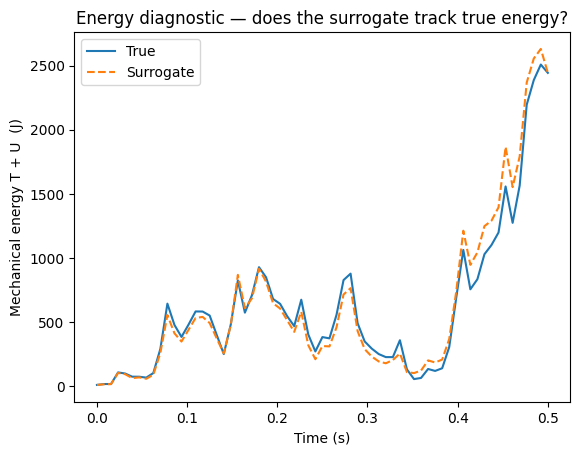

In [11]:
# 11) Energy E = T + U as a diagnostic
def mech_energy(x, v):
    return 0.5*m*v**2 + 0.5*k*x**2 + 0.25*alpha*k*x**4

E_true = mech_energy(sol_true.y[0], sol_true.y[1])
E_sur  = mech_energy(sol_sur.y[0],  sol_sur.y[1])

plt.figure()
plt.plot(sol_true.t, E_true,       label='True')
plt.plot(sol_sur .t, E_sur,  '--', label='Surrogate')
plt.xlabel('Time (s)')
plt.ylabel('Mechanical energy T + U  (J)')
plt.title('Energy diagnostic — does the surrogate track true energy?')
plt.legend()
plt.show()

## Grey-Box: Learn Only the Unknown Part

The black-box surrogate above learns **everything** — kinematics, linear restoring, damping, forcing, and the cubic nonlinearity — from data. But in most MBD problems we *know* most of the physics. We only need ML to capture the part we don't.

Here we keep $m,\,d,\,k$ fixed and assume the **cubic nonlinearity is unknown**.
The network learns a single scalar function $f_\theta(x)$ that approximates $\alpha k x^3$.
The rollout then uses

$$\dot x = v, \qquad \dot v \;=\; \frac{1}{m}\bigl(F - d\,v - k\,x - f_\theta(x)\bigr)$$

Three immediate consequences:
- The network is much smaller (a 1 → 1 mapping) and trains in seconds.
- The learned function is **interpretable** — plot it directly and check against intuition.
- Linearity, damping, and kinematics are exact, so the model degrades more gracefully along those axes.

Grey-box early stopping at epoch 273


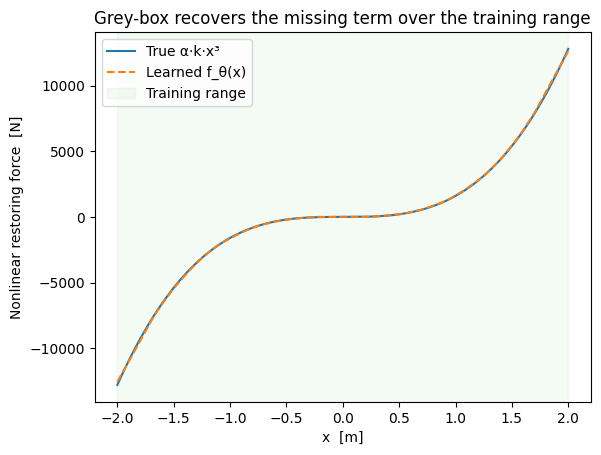

In [12]:
# 12) Grey-box: learn only the cubic restoring term

class CubicTermNN(nn.Module):
    """Learn f_θ(x) ≈ α·k·x³. Inputs and outputs in physical units."""
    def __init__(self, hidden=(32, 32)):
        super().__init__()
        layers = []
        in_dim = 1
        for h_ in hidden:
            layers += [nn.Linear(in_dim, h_), nn.SiLU()]
            in_dim = h_
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

# Recover cubic-term target from data:  α k x³ ≈ F − d v − k x − m·v̇
X_phys = torch.from_numpy(X).float().to(device)
Y_phys = torch.from_numpy(Y).float().to(device)
x_all, v_all, F_all = X_phys[:, 0:1], X_phys[:, 1:2], X_phys[:, 2:3]
dv_all = Y_phys[:, 1:2]
cubic_target = F_all - damp*v_all - k*x_all - m*dv_all

x_tr, t_tr = x_all[train_idx], cubic_target[train_idx]
x_va, t_va = x_all[val_idx],   cubic_target[val_idx]

loader_gb_tr = DataLoader(TensorDataset(x_tr, t_tr), batch_size=64, shuffle=True)
loader_gb_va = DataLoader(TensorDataset(x_va, t_va), batch_size=64, shuffle=False)

model_gb = CubicTermNN().to(device)
opt_gb = optim.AdamW(model_gb.parameters(), lr=1e-3, weight_decay=1e-4)

best_val_gb, no_imp, best_state_gb = float('inf'), 0, model_gb.state_dict()
for epoch in range(1, 1001):
    model_gb.train()
    for xb, tb in loader_gb_tr:
        opt_gb.zero_grad()
        nn.functional.mse_loss(model_gb(xb), tb).backward()
        opt_gb.step()
    model_gb.eval()
    with torch.no_grad():
        v_loss = sum(nn.functional.mse_loss(model_gb(xb), tb).item()
                     for xb, tb in loader_gb_va) / len(loader_gb_va)
    if v_loss < best_val_gb:
        best_val_gb, no_imp, best_state_gb = v_loss, 0, model_gb.state_dict()
    else:
        no_imp += 1
        if no_imp >= 30:
            print(f'Grey-box early stopping at epoch {epoch}')
            break
model_gb.load_state_dict(best_state_gb)

# Plot learned cubic vs. true α·k·x³ across the full training range
x_grid = torch.linspace(-2.0, 2.0, 200, device=device).unsqueeze(1)
with torch.no_grad():
    f_learned = model_gb(x_grid).cpu().numpy().ravel()
x_np = x_grid.cpu().numpy().ravel()

plt.figure()
plt.plot(x_np, alpha*k*x_np**3,    label='True α·k·x³')
plt.plot(x_np, f_learned, '--',    label='Learned f_θ(x)')
plt.axvspan(-2, 2, alpha=0.05, color='C2', label='Training range')
plt.xlabel('x  [m]')
plt.ylabel('Nonlinear restoring force  [N]')
plt.title('Grey-box recovers the missing term over the training range')
plt.legend()
plt.show()

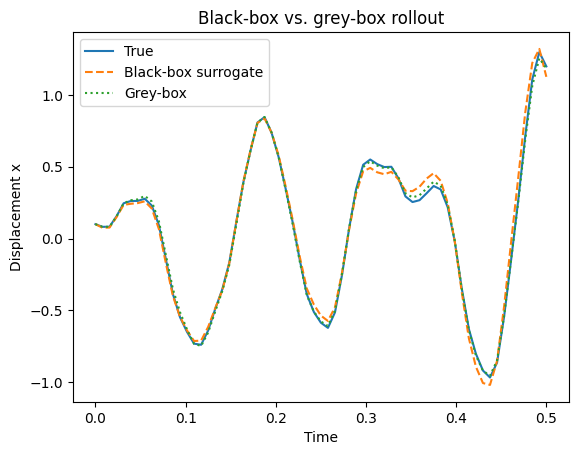

In [13]:
# 13) Grey-box rollout: known physics + learned cubic term
def greybox_rhs(t, u, forces, h):
    idx = min(int(t / h), len(forces) - 1)
    F_t = forces[idx]
    x, v = u
    x_t = torch.tensor([[x]], dtype=torch.float32, device=device)
    with torch.no_grad():
        f_cubic = float(model_gb(x_t).item())
    return [v, (F_t - damp*v - k*x - f_cubic) / m]

sol_gb = solve_ivp(fun=lambda t, y: greybox_rhs(t, y, forces, h),
                   t_span=t_span, y0=u0, t_eval=t_eval, method='RK45')

plt.figure()
plt.plot(sol_true.t, sol_true.y[0],       label='True')
plt.plot(sol_sur .t, sol_sur .y[0], '--', label='Black-box surrogate')
plt.plot(sol_gb  .t, sol_gb  .y[0], ':',  label='Grey-box')
plt.xlabel('Time')
plt.ylabel('Displacement x')
plt.title('Black-box vs. grey-box rollout')
plt.legend()
plt.show()

### When grey-box wins — and when it doesn't

**Wins when:**
- You can write down most of the physics confidently.
- The "unknown" part has a low-dimensional input — here, the cubic depends on $x$ alone.
- You care about interpretability or extrapolation along the known axes.

**Loses (or breaks) when:**
- The unknown depends on more variables than you wired in — e.g., velocity-dependent friction needs $f_\theta(x, v)$.
- The known physics itself is wrong (model-form error in $m$, $d$, or $k$).
- The dataset isn't rich enough to identify the unknown term separately from the known ones.

In practice, *how much physics do I bake in?* is a dial between fully data-driven (this notebook's MLP) and fully physical (no ML). Grey-box sits in the middle and is where most real engineering surrogates end up.

## Your Turn

Work through one or more tasks. Re-run the training and trajectory cells after each change.

### Try (5 min)

Increase **dropout rate** from `0.011` to `0.3` in the hyperparameter block and retrain.

- Does early stopping trigger earlier or later?
- Does the rollout trajectory improve or worsen?

*High dropout forces fewer neurons — helpful against overfitting, but too much hurts capacity.*

### Extend (5–10 min)

Replace the **activation function** from `nn.SiLU` to `nn.ReLU` and retrain.

- Compare the final validation loss
- Compare the rollout trajectories side by side

Can you see a difference? Which one produces smoother trajectories and why?

### Explore (open-ended)

Change `N` to `500` in the data generation cell and re-run from there.

- How does validation loss change?
- Does the rollout trajectory look different?
- At what point does data scarcity start to hurt?


## What's next?

- **2-2** Duffing Oscillator trained on system responses (not often we have access to underlying equations). 
- **2-3** Revisits _2-2_ to discuss Automatic Machine Learning techniques.